# Model 1: Road Closure Probability Prediction

**Objective**: Predict the probability (0-100%) of road closure for traffic events in Bengaluru

**Dataset**: Feature-engineered Astram event data (~8,200 events)

**Approach**:
- Binary classification with probabilistic output
- Calibrated probabilities for reliable risk assessment
- Train models independently (LightGBM, XGBoost, CatBoost)
- Manual single-model selection for tuning and downstream processing
- Threshold optimization for operational decision-making

In [102]:
%pip install optuna "optuna-integration[lightgbm]"

Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries

In [103]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    brier_score_loss, accuracy_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# Gradient Boosting Models
import lightgbm as lgb
import xgboost as xgb

# Hyperparameter optimization
import optuna
try:
    from optuna.integration import LightGBMPruningCallback
except ModuleNotFoundError:
    from optuna_integration.lightgbm import LightGBMPruningCallback

# Explainability
import shap

# Utilities
from datetime import datetime
import joblib
import os

print("All libraries imported successfully!")
print(f"Python environment ready - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries imported successfully!
Python environment ready - 2026-06-20 01:05:24


## 2. Load Feature-Engineered Dataset

In [104]:
# Load feature engineered datasets from local workspace
import os
from glob import glob

# Setup output directories
output_dir = os.path.join(os.getcwd(), 'outputs', 'model_road_closure')
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Dataset paths for Model 1 (road closure) and Model 2 handoff (duration)
ROAD_CLOSURE_DATA_PATH = 'model_ready_road_closure.csv'

# Target column names
ROAD_CLOSURE_TARGET = 'target_road_closure'

# Road-closure data is mandatory
if not os.path.exists(ROAD_CLOSURE_DATA_PATH):
    raise FileNotFoundError(
        f"Missing required file: {ROAD_CLOSURE_DATA_PATH}. "
        f"Current directory: {os.getcwd()}"
    )

road_closure_df = pd.read_csv(ROAD_CLOSURE_DATA_PATH)

print('Road-closure training data:', road_closure_df.shape)
# Backward compatibility for downstream cells that currently use `df`
df = road_closure_df.copy()
print(f"Active training dataframe set: {df.shape}")

Output directory: c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure
Road-closure training data: (8173, 516)
Active training dataframe set: (8173, 516)


## 3. Leakage Audit

This section identifies features that should not be used by Model 1 because they either encode endpoint/route-completion information or behave like near-perfect one-column predictors of `target_road_closure`. The detected columns are saved to a leakage audit CSV and excluded from training, inference features, artifacts, and the Model 2 handoff input columns.

In [105]:
raw_feature_cols = [col for col in road_closure_df.columns if col != ROAD_CLOSURE_TARGET]
road_closure_target = road_closure_df[ROAD_CLOSURE_TARGET].copy().astype(int)

LEAKAGE_NAME_PATTERNS = [
    'end_location',
    'end_point',
    'route_distance',
    'route_span',
]
LEAKAGE_BINARY_RULE_ACCURACY_THRESHOLD = 0.995
LEAKAGE_AUC_STRENGTH_THRESHOLD = 0.995
LEAKAGE_CORRELATION_THRESHOLD = 0.98

leakage_rows = []
for col in raw_feature_cols:
    lowered = col.lower()
    name_flag = any(pattern in lowered for pattern in LEAKAGE_NAME_PATTERNS)
    series = pd.to_numeric(road_closure_df[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    valid = series.notna() & road_closure_target.notna()
    auc_strength = np.nan
    correlation = np.nan
    binary_rule_accuracy = np.nan
    binary_rule_direction = ''

    if valid.sum() > 0 and road_closure_target.loc[valid].nunique() == 2:
        y_valid = road_closure_target.loc[valid]
        x_valid = series.loc[valid]
        if x_valid.nunique(dropna=True) > 1:
            correlation = x_valid.corr(y_valid)
            auc_value = roc_auc_score(y_valid, x_valid)
            auc_strength = max(auc_value, 1 - auc_value)

        unique_values = set(x_valid.dropna().unique())
        if unique_values.issubset({0, 1, 0.0, 1.0}):
            direct_pred = x_valid.astype(int)
            direct_accuracy = (direct_pred == y_valid).mean()
            inverted_accuracy = ((1 - direct_pred) == y_valid).mean()
            if direct_accuracy >= inverted_accuracy:
                binary_rule_accuracy = direct_accuracy
                binary_rule_direction = 'direct'
            else:
                binary_rule_accuracy = inverted_accuracy
                binary_rule_direction = 'inverted'

    auto_flag = (
        (pd.notna(binary_rule_accuracy) and binary_rule_accuracy >= LEAKAGE_BINARY_RULE_ACCURACY_THRESHOLD)
        or (pd.notna(auc_strength) and auc_strength >= LEAKAGE_AUC_STRENGTH_THRESHOLD)
        or (pd.notna(correlation) and abs(correlation) >= LEAKAGE_CORRELATION_THRESHOLD)
    )

    if name_flag or auto_flag:
        reasons = []
        if name_flag:
            reasons.append('name_pattern')
        if pd.notna(binary_rule_accuracy) and binary_rule_accuracy >= LEAKAGE_BINARY_RULE_ACCURACY_THRESHOLD:
            reasons.append('near_perfect_binary_rule')
        if pd.notna(auc_strength) and auc_strength >= LEAKAGE_AUC_STRENGTH_THRESHOLD:
            reasons.append('near_perfect_auc')
        if pd.notna(correlation) and abs(correlation) >= LEAKAGE_CORRELATION_THRESHOLD:
            reasons.append('near_perfect_correlation')

        leakage_rows.append(
            {
                'feature': col,
                'reasons': '|'.join(reasons),
                'binary_rule_accuracy': binary_rule_accuracy,
                'binary_rule_direction': binary_rule_direction,
                'auc_strength': auc_strength,
                'correlation': correlation,
                'non_null_rows': int(valid.sum()),
                'unique_values': int(series.nunique(dropna=True)),
            }
        )

leakage_audit_df = pd.DataFrame(
    leakage_rows,
    columns=[
        'feature',
        'reasons',
        'binary_rule_accuracy',
        'binary_rule_direction',
        'auc_strength',
        'correlation',
        'non_null_rows',
        'unique_values',
    ],
).sort_values(['binary_rule_accuracy', 'auc_strength', 'correlation'], ascending=False, na_position='last')

LEAKAGE_FEATURES = sorted(leakage_audit_df['feature'].tolist())
LEAKAGE_REVIEW_FEATURES = sorted(
    col for col in raw_feature_cols
    if col.startswith('past_closure_rate_') and col not in LEAKAGE_FEATURES
)

# Setup output path for leakage audit
LEAKAGE_AUDIT_PATH = os.path.join(output_dir, 'leakage_audit.csv')
leakage_audit_df.to_csv(LEAKAGE_AUDIT_PATH, index=False)

print(f'Saved leakage audit CSV: {LEAKAGE_AUDIT_PATH}')
print(f'Detected leakage features to exclude: {len(LEAKAGE_FEATURES)}')
for feature in LEAKAGE_FEATURES:
    print(f'  - {feature}')

print(f'Past target-rate features kept for review: {len(LEAKAGE_REVIEW_FEATURES)}')

Saved leakage audit CSV: c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure\leakage_audit.csv
Detected leakage features to exclude: 4
  - end_point_missing_or_zero
  - has_end_location
  - has_route_span
  - route_distance_km
Past target-rate features kept for review: 7


## 4. Data Preparation & Chronological Split

**Key Decision**: Use chronological split (not random) to avoid data leakage across time

In [106]:
# Identify target and feature columns
target_col = 'target_road_closure'

# Columns to exclude from features (leakage-prone or identifiers)
exclude_cols = [
    'target_road_closure',  # Target
    # Add any ID or leakage columns if present
    # 'id', 'event_id', 'closed_datetime', 'resolved_datetime', etc.
]

# Get feature columns (exclude target + leakage features)
feature_cols = [
    col for col in df.columns
    if col not in exclude_cols and col not in LEAKAGE_FEATURES
]

print(f"Total features available: {len(feature_cols)}")
print(f"\nFirst 20 features:")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"  {i}. {col}")
print(f"  ... and {len(feature_cols) - 20} more features")

# Prepare X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n Feature matrix: {X.shape}")
print(f" Target vector: {y.shape}")

Total features available: 511

First 20 features:
  1. latitude
  2. longitude
  3. valid_start_coordinate
  4. has_start_location
  5. distance_to_city_center_km
  6. start_hour
  7. start_dayofweek
  8. start_weekofyear
  9. is_weekend
  10. is_peak_hour
  11. is_night
  12. hour_sin
  13. hour_cos
  14. day_sin
  15. day_cos
  16. report_lag_minutes_clipped
  17. report_lag_hours_clipped
  18. report_lag_is_negative
  19. reporting_delay_minutes
  20. text_length
  ... and 491 more features

 Feature matrix: (8173, 511)
 Target vector: (8173,)


In [107]:
# Handle missing values
print("Missing values check:")
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"  └─ Total missing values: {missing.sum():,}")
    print(f"\n  Columns with missing values:")
    for col in missing[missing > 0].index:
        print(f"    • {col}: {missing[col]} ({missing[col]/len(X)*100:.2f}%)")

    # Fill missing values with median for numeric, mode for categorical
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['float64', 'int64']:
                X[col].fillna(X[col].median(), inplace=True)
            else:
                X[col].fillna(X[col].mode()[0], inplace=True)
    print(f"\n✓ Missing values imputed")
else:
    print("  └─ No missing values found ")

# Check for infinite values
inf_check = np.isinf(X.select_dtypes(include=[np.number])).sum()
if inf_check.sum() > 0:
    print(f"\nInfinite values found: {inf_check.sum()}")
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    print(" Infinite values handled")
else:
    print(" No infinite values found")

Missing values check:
  └─ No missing values found 
 No infinite values found


In [108]:
# Chronological split: 70% train, 15% validation, 15% test
# Assuming data is already sorted chronologically
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()

print("Chronological Split Summary:")
print(f"{'Split':<12} {'Rows':<10} {'Closure Rate':<15} {'Date Range'}")
print("="*60)
print(f"{'Train':<12} {len(X_train):<10,} {y_train.mean()*100:>6.2f}%")
print(f"{'Validation':<12} {len(X_val):<10,} {y_val.mean()*100:>6.2f}%")
print(f"{'Test':<12} {len(X_test):<10,} {y_test.mean()*100:>6.2f}%")
print("="*60)
print(f"{'Total':<12} {len(X):<10,} {y.mean()*100:>6.2f}%")

# Calculate class weights for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\n Positive class weight (for LightGBM/XGBoost): {scale_pos_weight:.2f}")

Chronological Split Summary:
Split        Rows       Closure Rate    Date Range
Train        5,721        6.54%
Validation   1,226       10.36%
Test         1,226       14.27%
Total        8,173        8.27%

 Positive class weight (for LightGBM/XGBoost): 14.30


## 5. Baseline Model - Logistic Regression

In [109]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression (interpretable baseline)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities
lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
lr_val_auc = roc_auc_score(y_val, lr_val_proba)
lr_val_prauc = average_precision_score(y_val, lr_val_proba)
lr_val_brier = brier_score_loss(y_val, lr_val_proba)
lr_val_acc = accuracy_score(y_val, (lr_val_proba >= 0.5).astype(int))

print("Logistic Regression (Baseline) - Validation Set:")
print(f"  ROC-AUC:     {lr_val_auc:.4f}")
print(f"  PR-AUC:      {lr_val_prauc:.4f}")
print(f"  Brier Score: {lr_val_brier:.4f} (lower is better)")
print(f"  Accuracy:    {lr_val_acc:.4f} (at 0.5 threshold)")
print(f"\n Baseline model trained")

Logistic Regression (Baseline) - Validation Set:
  ROC-AUC:     0.9907
  PR-AUC:      0.9517
  Brier Score: 0.0176 (lower is better)
  Accuracy:    0.9796 (at 0.5 threshold)

 Baseline model trained


## 6. LightGBM Model (Primary Model)

In [110]:
# LightGBM with default hyperparameters first
lgb_params = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Sanitize feature names for LightGBM
def sanitize_feature_names(df):
    new_columns = []
    for col in df.columns:
        # Replace problematic characters with underscore
        sanitized_col = ''.join(c if c.isalnum() or c == '_' else '_' for c in col)
        # Remove leading/trailing underscores and multiple underscores
        sanitized_col = '_'.join(filter(None, sanitized_col.split('_')))
        new_columns.append(sanitized_col)
    df.columns = new_columns
    return df

X_train_lgb = sanitize_feature_names(X_train.copy())
X_val_lgb = sanitize_feature_names(X_val.copy())
X_test_lgb = sanitize_feature_names(X_test.copy())

# Create LightGBM datasets with feature_pre_filter=False
lgb_train = lgb.Dataset(X_train_lgb, y_train, params={'feature_pre_filter': False})
lgb_val = lgb.Dataset(X_val_lgb, y_val, reference=lgb_train, params={'feature_pre_filter': False})

# Train with early stopping
print("Training LightGBM (default params)...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Predict probabilities
lgb_val_proba = lgb_model.predict(X_val_lgb, num_iteration=lgb_model.best_iteration)
lgb_test_proba = lgb_model.predict(X_test_lgb, num_iteration=lgb_model.best_iteration)

# Evaluate
lgb_val_auc = roc_auc_score(y_val, lgb_val_proba)
lgb_val_prauc = average_precision_score(y_val, lgb_val_proba)
lgb_val_brier = brier_score_loss(y_val, lgb_val_proba)
lgb_val_acc = accuracy_score(y_val, (lgb_val_proba >= 0.5).astype(int))

print("\nLightGBM - Validation Set:")
print(f"  ROC-AUC:     {lgb_val_auc:.4f}")
print(f"  PR-AUC:      {lgb_val_prauc:.4f}")
print(f"  Brier Score: {lgb_val_brier:.4f}")
print(f"  Accuracy:    {lgb_val_acc:.4f} (at 0.5 threshold)")
print(f"  Best iteration: {lgb_model.best_iteration}")
print(f"\n LightGBM trained with {lgb_model.num_trees()} trees")

Training LightGBM (default params)...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.999993	train's binary_logloss: 0.00728245	valid's auc: 0.999262	valid's binary_logloss: 0.0209419
Early stopping, best iteration is:
[111]	train's auc: 0.999994	train's binary_logloss: 0.00540972	valid's auc: 0.999305	valid's binary_logloss: 0.0201021

LightGBM - Validation Set:
  ROC-AUC:     0.9993
  PR-AUC:      0.9931
  Brier Score: 0.0053
  Accuracy:    0.9918 (at 0.5 threshold)
  Best iteration: 111

 LightGBM trained with 111 trees


## 7. XGBoost Model

In [111]:
# XGBoost with default hyperparameters
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'logloss'],
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1
}

# Create DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train with early stopping
print("Training XGBoost (default params)...")
evals = [(dtrain, 'train'), (dval, 'valid')]
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predict probabilities
xgb_val_proba = xgb_model.predict(dval, iteration_range=(0, xgb_model.best_iteration))
xgb_test_proba = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration))

# Evaluate
xgb_val_auc = roc_auc_score(y_val, xgb_val_proba)
xgb_val_prauc = average_precision_score(y_val, xgb_val_proba)
xgb_val_brier = brier_score_loss(y_val, xgb_val_proba)
xgb_val_acc = accuracy_score(y_val, (xgb_val_proba >= 0.5).astype(int))

print("\nXGBoost - Validation Set:")
print(f"  ROC-AUC:     {xgb_val_auc:.4f}")
print(f"  PR-AUC:      {xgb_val_prauc:.4f}")
print(f"  Brier Score: {xgb_val_brier:.4f}")
print(f"  Accuracy:    {xgb_val_acc:.4f} (at 0.5 threshold)")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"\n XGBoost trained with {xgb_model.best_iteration} trees")

Training XGBoost (default params)...
[0]	train-auc:0.98927	train-logloss:0.64650	valid-auc:0.97518	valid-logloss:0.64694
[100]	train-auc:1.00000	train-logloss:0.01483	valid-auc:0.99937	valid-logloss:0.02939
[200]	train-auc:1.00000	train-logloss:0.00311	valid-auc:0.99939	valid-logloss:0.02086
[300]	train-auc:1.00000	train-logloss:0.00152	valid-auc:0.99941	valid-logloss:0.02002
[322]	train-auc:1.00000	train-logloss:0.00136	valid-auc:0.99938	valid-logloss:0.02014

XGBoost - Validation Set:
  ROC-AUC:     0.9994
  PR-AUC:      0.9947
  Brier Score: 0.0054
  Accuracy:    0.9918 (at 0.5 threshold)
  Best iteration: 272

 XGBoost trained with 272 trees


## 8. Hyperparameter Optimization + Ensemble Training

Both LightGBM and XGBoost are independently tuned via Optuna, trained with best params, individually calibrated, then combined into a soft-voting ensemble (equal-weight probability averaging).

In [112]:
N_TRIALS = 30
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── LightGBM Optuna study ────────────────────────────────────────────────────
def objective_lgb(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
    }
    model = lgb.train(
        params, lgb_train, num_boost_round=700,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )
    preds = model.predict(X_val_lgb, num_iteration=model.best_iteration)
    return average_precision_score(y_val, preds)

print("Tuning LightGBM...")
study_lgb = optuna.create_study(direction='maximize', study_name='lightgbm_tuning')
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
best_params_lgb = study_lgb.best_params
print(f"LightGBM Best PR-AUC: {study_lgb.best_value:.4f}")
print(f"Best params: {best_params_lgb}\n")

# ── XGBoost Optuna study ─────────────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.train(
        params, dtrain, num_boost_round=700,
        evals=[(dval, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    preds = model.predict(dval, iteration_range=(0, model.best_iteration))
    return average_precision_score(y_val, preds)

print("Tuning XGBoost...")
study_xgb = optuna.create_study(direction='maximize', study_name='xgboost_tuning')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
best_params_xgb = study_xgb.best_params
print(f"XGBoost Best PR-AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {best_params_xgb}")

Tuning LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 0.995386:   3%|▎         | 1/30 [00:01<00:49,  1.71s/it]

Early stopping, best iteration is:
[152]	valid_0's auc: 0.999484
Training until validation scores don't improve for 50 rounds


...

Early stopping, best iteration is:
[132]	valid_0's auc: 0.999534
Training until validation scores don't improve for 50 rounds


Best trial: 23. Best value: 0.997207: 100%|██████████| 30/30 [01:14<00:00,  2.47s/it]


Early stopping, best iteration is:
[95]	valid_0's auc: 0.999527
LightGBM Best PR-AUC: 0.9972
Best params: {'num_leaves': 19, 'max_depth': 4, 'learning_rate': 0.04393850056331491, 'min_child_samples': 100, 'subsample': 0.6527513242039169, 'colsample_bytree': 0.9012560144449463, 'reg_alpha': 1.5389930676743671e-06, 'reg_lambda': 0.00026868876973389696}

Tuning XGBoost...


Best trial: 25. Best value: 0.995955: 100%|██████████| 30/30 [01:11<00:00,  2.39s/it]

XGBoost Best PR-AUC: 0.9960
Best params: {'max_depth': 5, 'learning_rate': 0.02742523034405825, 'subsample': 0.9578073733787156, 'colsample_bytree': 0.7220720600894988, 'gamma': 0.0035886761549973247}


In [113]:
# ── Wrapper & calibration classes ────────────────────────────────────────────
from sklearn.base import BaseEstimator, ClassifierMixin

class XGBWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        dmat = xgb.DMatrix(X)
        proba = self.model.predict(dmat, iteration_range=(0, self.model.best_iteration))
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class LGBMWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, feature_sanitizer_func, feature_names):
        self.model = model
        self.feature_sanitizer_func = feature_sanitizer_func
        self.feature_names = feature_names
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = len(feature_names)
        self._estimator_type = 'classifier'

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=self.feature_names)
        else:
            X_df = X.copy()
        X_sanitized = self.feature_sanitizer_func(X_df)
        proba = self.model.predict(X_sanitized, num_iteration=self.model.best_iteration)
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class SigmoidCalibratedModel(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator
        self.calibrator = LogisticRegression(solver='lbfgs')
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

    def fit(self, X, y):
        raw_probs = self.base_estimator.predict_proba(X)[:, 1].reshape(-1, 1)
        self.calibrator.fit(raw_probs, y)
        return self

    def predict_proba(self, X):
        raw_probs = self.base_estimator.predict_proba(X)[:, 1].reshape(-1, 1)
        calibrated_probs = self.calibrator.predict_proba(raw_probs)[:, 1]
        return np.vstack([1 - calibrated_probs, calibrated_probs]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class EnsembleModel(BaseEstimator, ClassifierMixin):
    """Soft-voting ensemble: equal-weight average of two calibrated models."""
    def __init__(self, model_lgb, model_xgb):
        self.model_lgb = model_lgb
        self.model_xgb = model_xgb
        self.classes_ = np.array([0, 1])
        self._estimator_type = 'classifier'

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        p_lgb = self.model_lgb.predict_proba(X)[:, 1]
        p_xgb = self.model_xgb.predict_proba(X)[:, 1]
        ensemble = 0.5 * p_lgb + 0.5 * p_xgb
        return np.vstack([1 - ensemble, ensemble]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# ── Train final LightGBM ─────────────────────────────────────────────────────
print("Training final LightGBM with best params...")
lgb_final_params = {
    'objective': 'binary',
    'metric': ['auc', 'binary_logloss'],
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'random_state': 42,
    **best_params_lgb
}
final_lgb_model = lgb.train(
    lgb_final_params, lgb_train, num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)
lgb_prefit = LGBMWrapper(final_lgb_model, sanitize_feature_names, feature_cols)
calibrated_lgb = SigmoidCalibratedModel(lgb_prefit)
calibrated_lgb.fit(X_val, y_val)

lgb_raw_val  = lgb_prefit.predict_proba(X_val)[:, 1]
lgb_raw_test = lgb_prefit.predict_proba(X_test)[:, 1]
lgb_cal_val  = calibrated_lgb.predict_proba(X_val)[:, 1]
lgb_cal_test = calibrated_lgb.predict_proba(X_test)[:, 1]

lgb_prauc_raw = average_precision_score(y_val, lgb_raw_val)
lgb_prauc_cal = average_precision_score(y_val, lgb_cal_val)
lgb_brier_raw = brier_score_loss(y_val, lgb_raw_val)
lgb_brier_cal = brier_score_loss(y_val, lgb_cal_val)
print(f"LightGBM  PR-AUC raw={lgb_prauc_raw:.4f}  cal={lgb_prauc_cal:.4f}")
print(f"LightGBM  Brier  raw={lgb_brier_raw:.4f}  cal={lgb_brier_cal:.4f}")

# ── Train final XGBoost ──────────────────────────────────────────────────────
print("\nTraining final XGBoost with best params...")
xgb_final_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    **best_params_xgb
}
final_xgb_model = xgb.train(
    xgb_final_params, dtrain, num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)
xgb_prefit = XGBWrapper(final_xgb_model)
calibrated_xgb = SigmoidCalibratedModel(xgb_prefit)
calibrated_xgb.fit(X_val, y_val)

xgb_raw_val  = xgb_prefit.predict_proba(X_val)[:, 1]
xgb_raw_test = xgb_prefit.predict_proba(X_test)[:, 1]
xgb_cal_val  = calibrated_xgb.predict_proba(X_val)[:, 1]
xgb_cal_test = calibrated_xgb.predict_proba(X_test)[:, 1]

xgb_prauc_raw = average_precision_score(y_val, xgb_raw_val)
xgb_prauc_cal = average_precision_score(y_val, xgb_cal_val)
xgb_brier_raw = brier_score_loss(y_val, xgb_raw_val)
xgb_brier_cal = brier_score_loss(y_val, xgb_cal_val)
print(f"XGBoost   PR-AUC raw={xgb_prauc_raw:.4f}  cal={xgb_prauc_cal:.4f}")
print(f"XGBoost   Brier  raw={xgb_brier_raw:.4f}  cal={xgb_brier_cal:.4f}")

# ── Build ensemble ───────────────────────────────────────────────────────────
calibrated_model = EnsembleModel(calibrated_lgb, calibrated_xgb)

ensemble_val_proba  = calibrated_model.predict_proba(X_val)[:, 1]
ensemble_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Aliases used by downstream cells
calibrated_val_proba  = ensemble_val_proba
calibrated_test_proba = ensemble_test_proba
calibrated_probs_test = ensemble_test_proba
raw_val_proba         = 0.5 * lgb_raw_val + 0.5 * xgb_raw_val  # pre-calibration average
raw_probs_test        = 0.5 * lgb_raw_test + 0.5 * xgb_raw_test

before_brier = brier_score_loss(y_val, raw_val_proba)
after_brier  = brier_score_loss(y_val, ensemble_val_proba)
before_prauc = average_precision_score(y_val, raw_val_proba)
after_prauc  = average_precision_score(y_val, ensemble_val_proba)

# For SHAP (LightGBM component used as interpreter)
final_model_raw = final_lgb_model

print(f"\nEnsemble  PR-AUC (val):  {after_prauc:.4f}")
print(f"Ensemble  Brier  (val):  {after_brier:.4f}")
print("\n Both models trained, calibrated, and combined into ensemble")

Training final LightGBM with best params...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.999306	train's binary_logloss: 0.0332013	valid's auc: 0.99952	valid's binary_logloss: 0.0302345
[200]	train's auc: 0.999926	train's binary_logloss: 0.0145178	valid's auc: 0.999685	valid's binary_logloss: 0.0188473
Early stopping, best iteration is:
[180]	train's auc: 0.999885	train's binary_logloss: 0.0169634	valid's auc: 0.999685	valid's binary_logloss: 0.0199053
LightGBM  PR-AUC raw=0.9972  cal=0.9972
LightGBM  Brier  raw=0.0045  cal=0.0042

Training final XGBoost with best params...
[0]	train-aucpr:0.26020	valid-aucpr:0.21889
[100]	train-aucpr:0.99593	valid-aucpr:0.98665
[200]	train-aucpr:0.99983	valid-aucpr:0.99323
[300]	train-aucpr:1.00000	valid-aucpr:0.99478
[400]	train-aucpr:1.00000	valid-aucpr:0.99556
[500]	train-aucpr:1.00000	valid-aucpr:0.99590
[573]	train-aucpr:1.00000	valid-aucpr:0.99582
XGBoost   PR-AUC raw=0.9960  cal=0.9960
XGBoost   Brier  raw=0.

### Probability Granularity Inspection
Compare individual model probabilities versus the ensemble output.

In [114]:
# Compare LightGBM, XGBoost, and Ensemble probabilities on the test set
inspection_df = pd.DataFrame({
    'LGB_Calibrated':      lgb_cal_test,
    'XGB_Calibrated':      xgb_cal_test,
    'Ensemble_Probability': ensemble_test_proba,
    'Actual_Label':         y_test.values
})

print("Sample of Granular Predictions (First 15 Test Cases):")
display(inspection_df.head(15))

granular_count = inspection_df[
    (inspection_df['Ensemble_Probability'] > 0.01) &
    (inspection_df['Ensemble_Probability'] < 0.99)
].shape[0]
print(f"\nEnsemble nuanced predictions (1%–99%): {granular_count} out of {len(X_test)}")

Sample of Granular Predictions (First 15 Test Cases):


,LGB_Calibrated,XGB_Calibrated,Ensemble_Probability,Actual_Label
0,0.007206,0.009131,0.008168,0
1,0.007143,0.009128,0.008136,0
2,0.007235,0.009121,0.008178,0
3,0.008090,0.009137,0.008613,0
4,0.008724,0.009236,0.008980,0
5,0.007229,0.009134,0.008181,0
6,0.007358,0.009128,0.008243,0
7,0.007236,0.009132,0.008184,0
8,0.007499,0.009151,0.008325,0
9,0.007149,0.009128,0.008138,0



Ensemble nuanced predictions (1%–99%): 232 out of 1226


## 9. Calibration Review

Calibration is already applied in Section 8; this section only visualizes the impact.

In [115]:
print("Calibration completed in Section 8 for both models.\n")
print(f"{'Model':<18} {'PR-AUC (raw)':<16} {'PR-AUC (cal)':<16} {'Brier (raw)':<14} {'Brier (cal)'}")
print("="*76)
print(f"{'LightGBM':<18} {lgb_prauc_raw:<16.4f} {lgb_prauc_cal:<16.4f} {lgb_brier_raw:<14.4f} {lgb_brier_cal:.4f}")
print(f"{'XGBoost':<18} {xgb_prauc_raw:<16.4f} {xgb_prauc_cal:<16.4f} {xgb_brier_raw:<14.4f} {xgb_brier_cal:.4f}")
print(f"{'Ensemble':<18} {before_prauc:<16.4f} {after_prauc:<16.4f} {before_brier:<14.4f} {after_brier:.4f}")

Calibration completed in Section 8 for both models.

Model              PR-AUC (raw)     PR-AUC (cal)     Brier (raw)    Brier (cal)
LightGBM           0.9972           0.9972           0.0045         0.0042
XGBoost            0.9960           0.9960           0.0055         0.0062
Ensemble           0.9965           0.9967           0.0046         0.0049


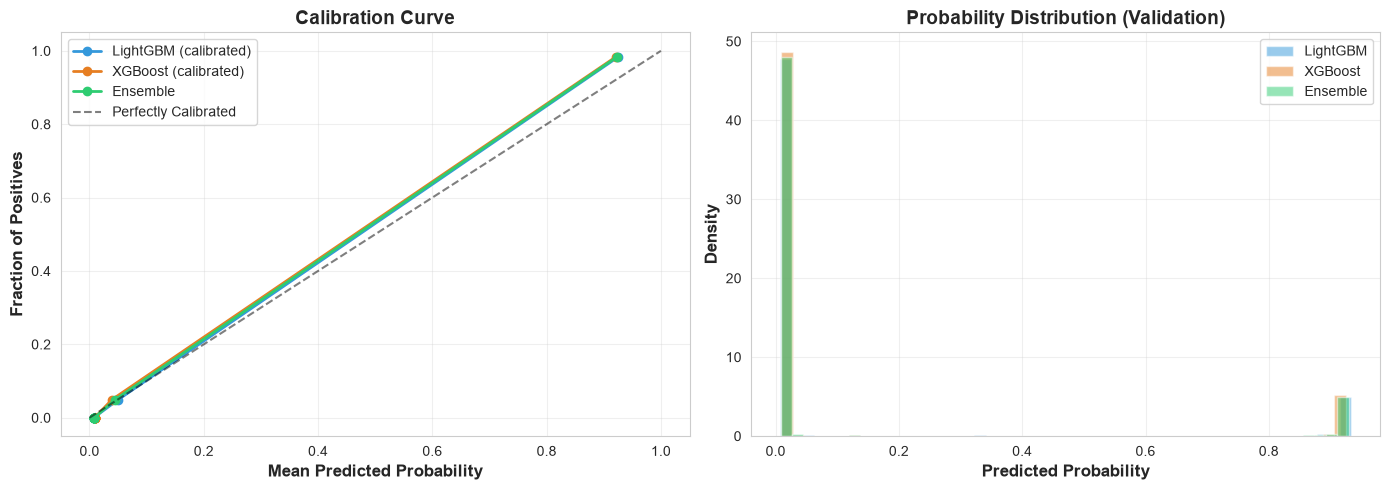

✓ Calibration analysis complete


In [116]:
# Visualize calibration curves for both models and the ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Calibration curve (calibrated components + ensemble)
for proba, label, color in [
    (lgb_cal_val,        'LightGBM (calibrated)', '#3498db'),
    (xgb_cal_val,        'XGBoost (calibrated)',  '#e67e22'),
    (ensemble_val_proba, 'Ensemble',              '#2ecc71'),
]:
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, marker='o', linewidth=2, label=label, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', alpha=0.5)
axes[0].set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
axes[0].set_title('Calibration Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Plot 2: Predicted probability distribution (val set)
axes[1].hist(lgb_cal_val,        bins=50, alpha=0.5, label='LightGBM', color='#3498db', density=True)
axes[1].hist(xgb_cal_val,        bins=50, alpha=0.5, label='XGBoost',  color='#e67e22', density=True)
axes[1].hist(ensemble_val_proba, bins=50, alpha=0.5, label='Ensemble', color='#2ecc71', density=True)
axes[1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1].set_title('Probability Distribution (Validation)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Calibration analysis complete")

## 10. Threshold Optimization

Find optimal threshold for operational decision-making (prioritizing Recall)

In [117]:
from sklearn.metrics import precision_score, recall_score

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_val, calibrated_val_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_scores)

# SETTING LOGICAL THRESHOLD: Using the threshold that maximizes F1-score
# This balances Precision and Recall instead of being overly sensitive.
optimal_threshold = thresholds[best_f1_idx]

print("Threshold Analysis (Balanced Approach):")
print("="*70)
print(f" Selected Optimal Threshold: {optimal_threshold:.4f}")
print(f"   (This balances false positives and missed closures using the F1-metric)")

# Verification at this threshold
val_preds_at_thresh = (calibrated_val_proba >= optimal_threshold).astype(int)
print(f"\nValidation Metrics at {optimal_threshold:.4f}:")
print(f"   Precision: {precision_score(y_val, val_preds_at_thresh):.4f}")
print(f"   Recall:    {recall_score(y_val, val_preds_at_thresh):.4f}")
print("="*70)

Threshold Analysis (Balanced Approach):
 Selected Optimal Threshold: 0.2741
   (This balances false positives and missed closures using the F1-metric)

Validation Metrics at 0.2741:
   Precision: 0.9692
   Recall:    0.9921


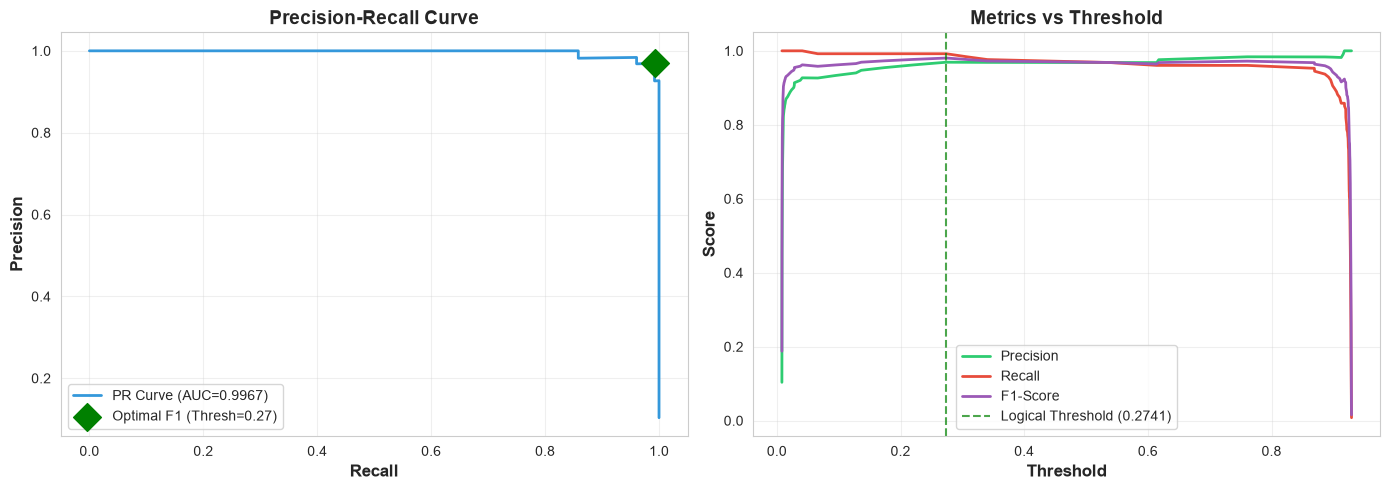

 Threshold visualization updated and fixed.


In [118]:
# Visualize Precision-Recall tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall Curve
axes[0].plot(recall, precision, linewidth=2, color='#3498db', label=f'PR Curve (AUC={after_prauc:.4f})')

# Highlight the logical threshold point
axes[0].scatter([recall[best_f1_idx]], [precision[best_f1_idx]], s=200, c='green',
                marker='D', zorder=5, label=f'Optimal F1 (Thresh={optimal_threshold:.2f})')

axes[0].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Plot 2: Metrics vs Threshold
axes[1].plot(thresholds, precision[:-1], label='Precision', linewidth=2, color='#2ecc71')
axes[1].plot(thresholds, recall[:-1], label='Recall', linewidth=2, color='#e74c3c')
axes[1].plot(thresholds, f1_scores, label='F1-Score', linewidth=2, color='#9b59b6')

axes[1].axvline(optimal_threshold, color='green', linestyle='--', alpha=0.7,
                label=f'Logical Threshold ({optimal_threshold:.4f})')

axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Threshold visualization updated and fixed.")

## 11. Test Set Evaluation

In [119]:
# Final evaluation on TEST set using the ensemble
test_probs    = ensemble_test_proba
test_roc_auc  = roc_auc_score(y_test, test_probs)
test_prauc    = average_precision_score(y_test, test_probs)
test_preds    = (test_probs >= optimal_threshold).astype(int)
test_acc      = accuracy_score(y_test, test_preds)
cm            = confusion_matrix(y_test, test_preds)

print("="*70)
print("FINAL ENSEMBLE (LightGBM + XGBoost) EVALUATION - TEST SET")
print("="*70)
print(f"ROC-AUC:  {test_roc_auc:.4f}")
print(f"PR-AUC:   {test_prauc:.4f}")
print(f"Accuracy: {test_acc:.4f} (at {optimal_threshold:.4f} threshold)")
print(f"\nUsing calculated optimal F1-threshold: {optimal_threshold:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['No Closure', 'Road Closure']))
print("\nConfusion Matrix:")
print(cm)
print("="*70)

# Alias used by downstream cells
test_probs_xgb   = test_probs
test_roc_auc_xgb = test_roc_auc
test_prauc_xgb   = test_prauc

FINAL ENSEMBLE (LightGBM + XGBoost) EVALUATION - TEST SET
ROC-AUC:  0.9972
PR-AUC:   0.9786
Accuracy: 0.9886 (at 0.2741 threshold)

Using calculated optimal F1-threshold: 0.2741

Classification Report:
              precision    recall  f1-score   support

  No Closure       1.00      0.99      0.99      1051
Road Closure       0.95      0.97      0.96       175

    accuracy                           0.99      1226
   macro avg       0.97      0.98      0.98      1226
weighted avg       0.99      0.99      0.99      1226


Confusion Matrix:
[[1042    9]
 [   5  170]]


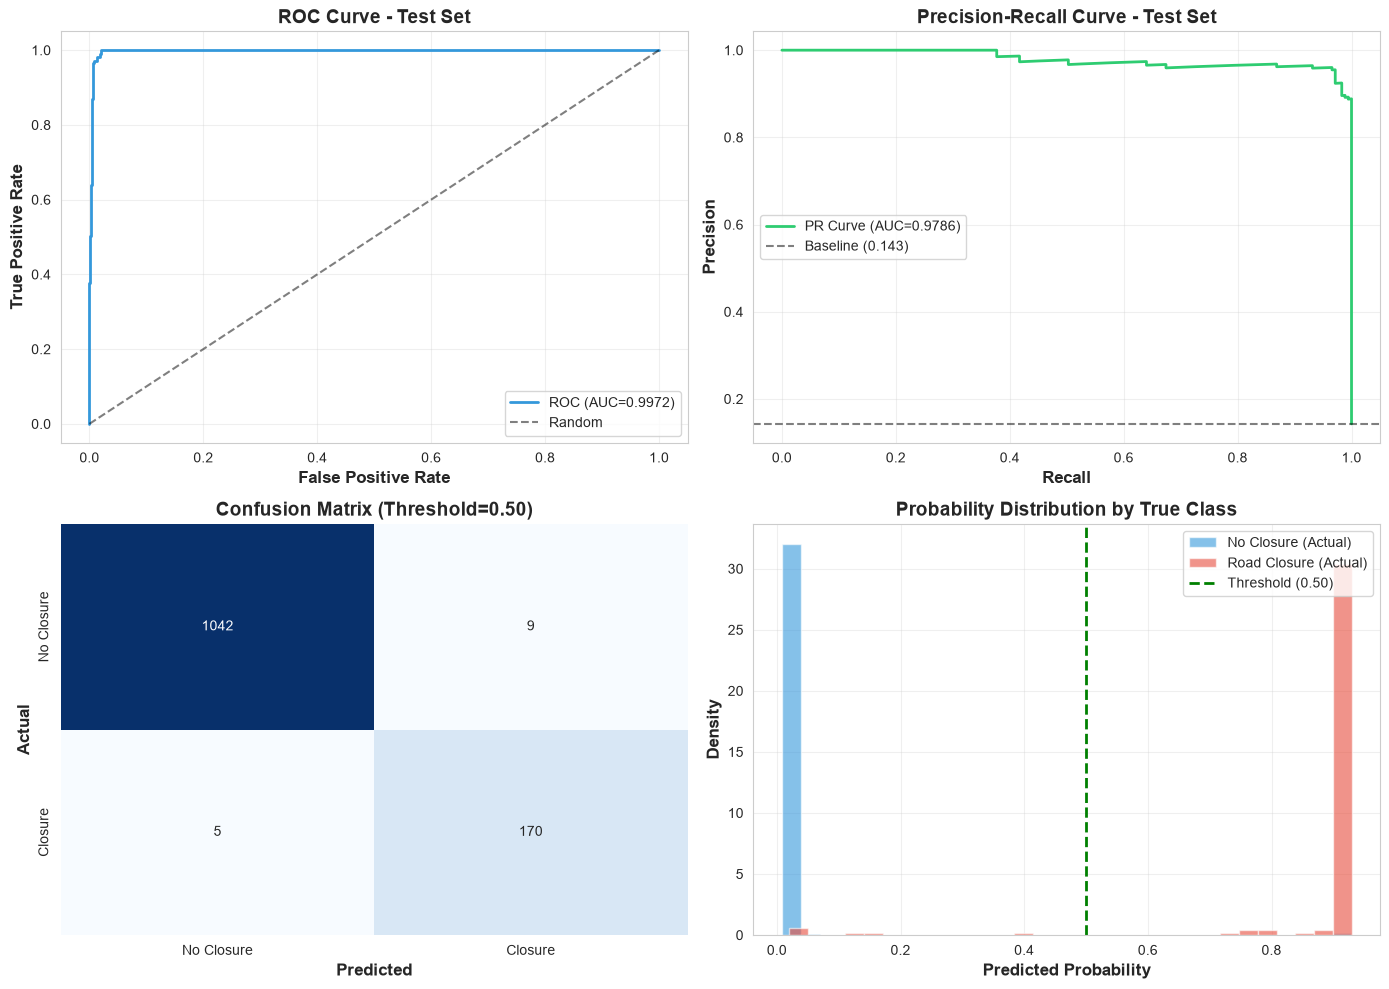

 Test set evaluation complete


In [120]:
# Visualize test set performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, calibrated_test_proba)
axes[0, 0].plot(fpr, tpr, linewidth=2, color='#3498db', label=f'ROC (AUC={test_roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0, 0].set_title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
precision_test, recall_test, _ = precision_recall_curve(y_test, calibrated_test_proba)
axes[0, 1].plot(recall_test, precision_test, linewidth=2, color='#2ecc71',
                label=f'PR Curve (AUC={test_prauc:.4f})')
axes[0, 1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5,
                   label=f'Baseline ({y_test.mean():.3f})')
axes[0, 1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Precision-Recall Curve - Test Set', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1, 0],
            xticklabels=['No Closure', 'Closure'],
            yticklabels=['No Closure', 'Closure'])
axes[1, 0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Confusion Matrix (Threshold=0.50)', fontsize=14, fontweight='bold')

# Plot 4: Predicted Probability Distribution by True Class
axes[1, 1].hist(calibrated_test_proba[y_test == 0], bins=30, alpha=0.6,
                label='No Closure (Actual)', color='#3498db', density=True)
axes[1, 1].hist(calibrated_test_proba[y_test == 1], bins=30, alpha=0.6,
                label='Road Closure (Actual)', color='#e74c3c', density=True)
axes[1, 1].axvline(0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.50)')
axes[1, 1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Probability Distribution by True Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Test set evaluation complete")

## 12. Feature Importance Analysis

Top 20 Features — LightGBM:
                                                 feature  importance
                                             text_length   100002.45
                                 description_char_length    29692.95
                                  description_word_count     2764.33
                  past_closure_rate_event_cause_corridor     1090.41
                              report_lag_minutes_clipped      802.39
cause_peak_interaction_grouped_construction_morning_peak      705.92
                           past_closure_rate_event_cause      675.54
                                                hour_sin      644.51
                                      is_breakdown_event      516.82
                                            has_jam_word      439.69
                         corridor_grouped_bellary_road_1      439.18
                         past_count_event_cause_corridor      409.98
                                                latitude      379.86
      

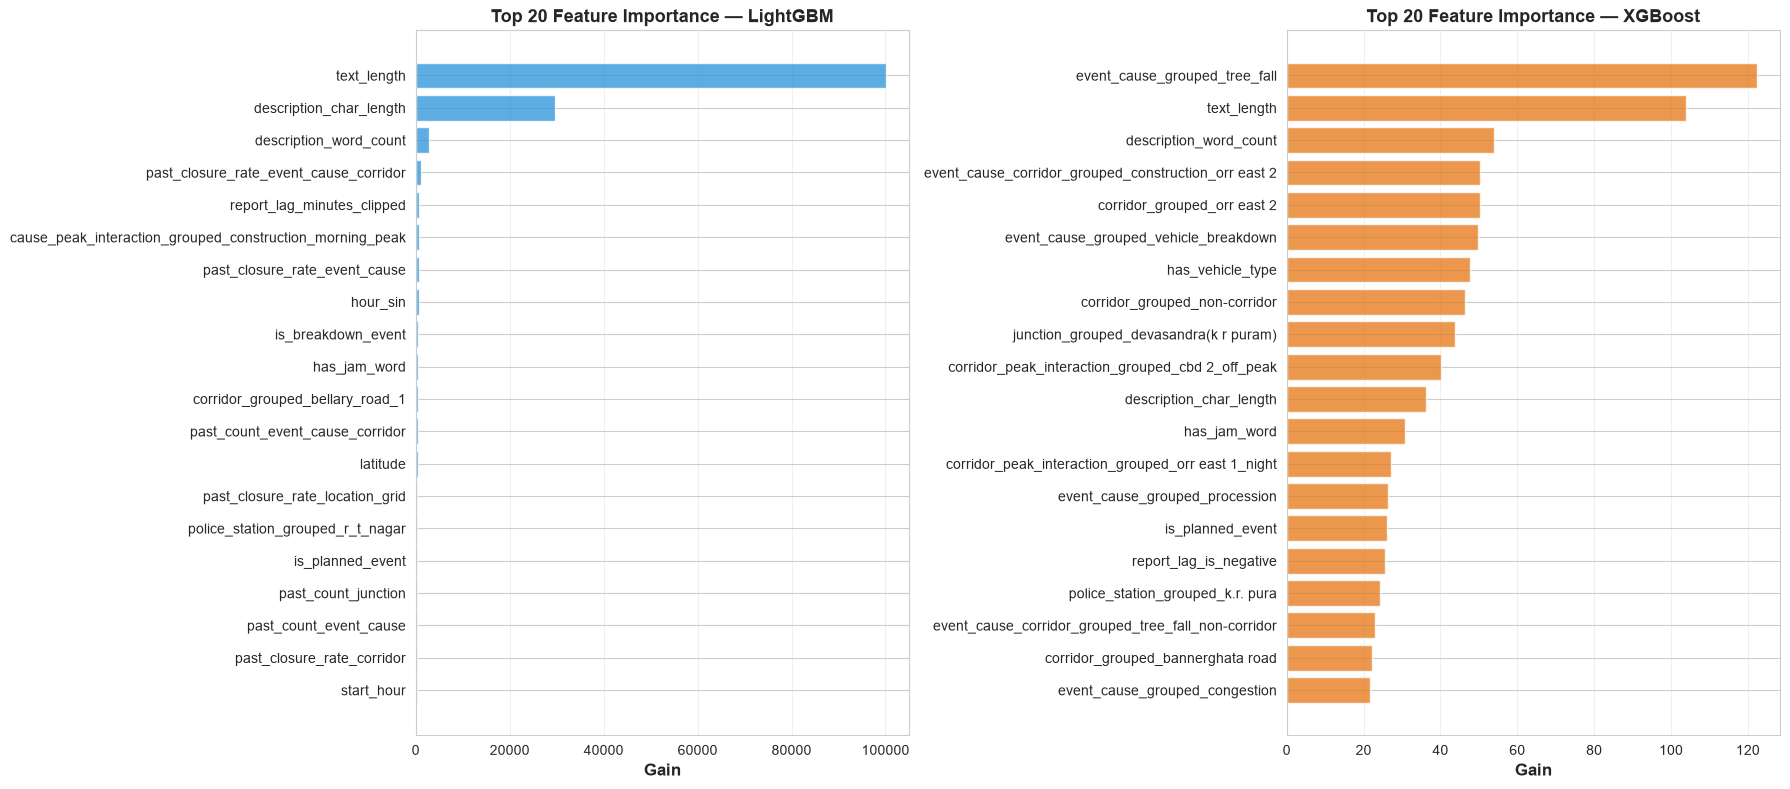


 Feature importance for both ensemble components shown


In [121]:
# Feature importance for both ensemble components
lgb_importance = pd.DataFrame({
    'feature':    X_train_lgb.columns,
    'importance': final_lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)

xgb_importance_dict = final_xgb_model.get_score(importance_type='gain')
xgb_importance = pd.DataFrame({
    'feature':    list(xgb_importance_dict.keys()),
    'importance': list(xgb_importance_dict.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_lgb = lgb_importance.head(20).copy()
top_xgb = xgb_importance.head(20).copy()

print("Top 20 Features — LightGBM:")
print(top_lgb.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("\nTop 20 Features — XGBoost:")
print(top_xgb.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(top_lgb['feature'][::-1], top_lgb['importance'][::-1], color='#3498db', alpha=0.8)
axes[0].set_xlabel('Gain', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Feature Importance — LightGBM', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_xgb['feature'][::-1], top_xgb['importance'][::-1], color='#e67e22', alpha=0.8)
axes[1].set_xlabel('Gain', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 Feature Importance — XGBoost', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Use LightGBM importance as the shared reference (also used by SHAP)
feature_importance = lgb_importance
top_features = top_lgb
print("\n Feature importance for both ensemble components shown")

## 13. SHAP Explainability

Understand **why** specific probabilities are predicted

In [122]:
# Create SHAP explainer (subsample for speed)
print("Creating SHAP explainer...")
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(final_model_raw)
shap_values = explainer.shap_values(X_test_sample)

print(f" SHAP values computed for {sample_size} test samples")

Creating SHAP explainer...
 SHAP values computed for 500 test samples


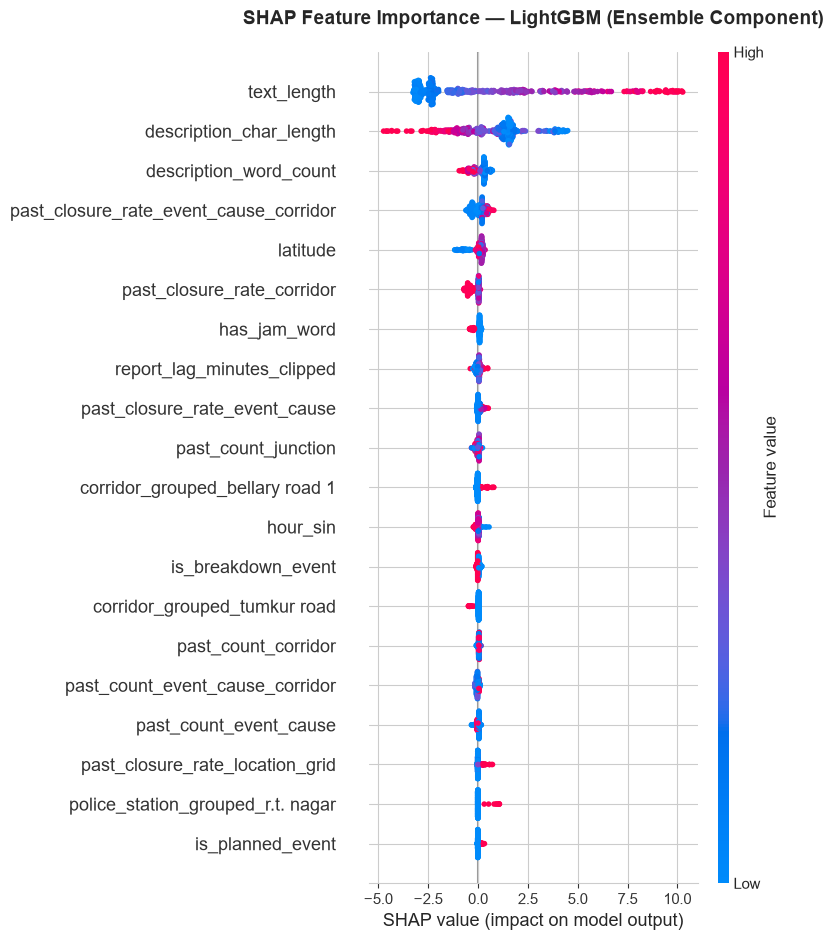

 SHAP summary plot generated


In [123]:
# SHAP Summary Plot — LightGBM component (tree-level interpretability)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols,
                  max_display=20, show=False)
plt.title('SHAP Feature Importance — LightGBM (Ensemble Component)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(" SHAP summary plot generated")

Explaining individual predictions:

High-Risk Event: 92.94% closure probability
Low-Risk Event:  0.81% closure probability


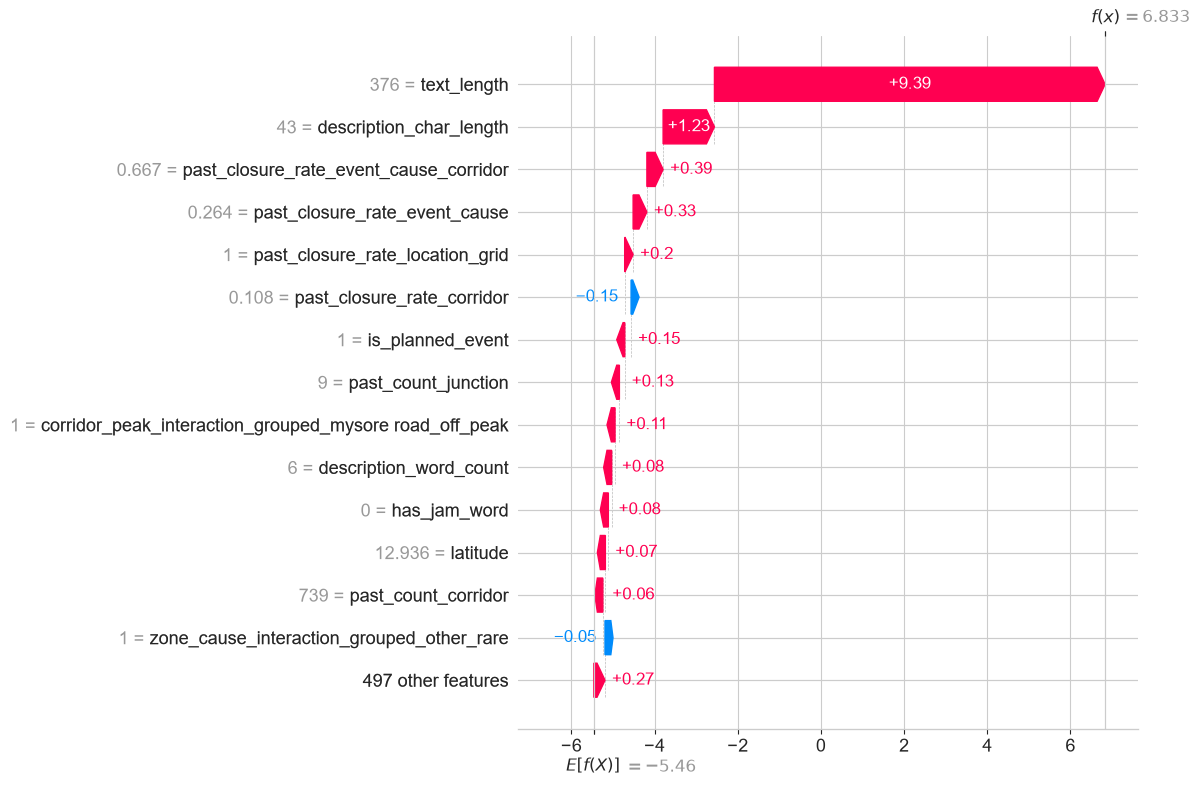


 Individual prediction explanation generated


In [124]:
# Example: Explain specific high-risk and low-risk predictions
test_probas_sample = calibrated_model.predict_proba(X_test_sample)[:, 1]

# Find high-risk example (high probability of closure)
high_risk_idx = test_probas_sample.argmax()
high_risk_prob = test_probas_sample[high_risk_idx]

# Find low-risk example (low probability of closure)
low_risk_idx = test_probas_sample.argmin()
low_risk_prob = test_probas_sample[low_risk_idx]

print("Explaining individual predictions:\n")
print(f"High-Risk Event: {high_risk_prob*100:.2f}% closure probability")
print(f"Low-Risk Event:  {low_risk_prob*100:.2f}% closure probability")

# Waterfall plot for high-risk event
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[high_risk_idx],
        feature_names=feature_cols
    ),
    max_display=15,
    show=True
)

print("\n Individual prediction explanation generated")

## 14. Save Final Model & Artifacts

In [125]:
# Configuration already done in data loading cell
# All paths point to ./outputs/model_road_closure/
print(f" Ready to save outputs to: {output_dir}")

 Ready to save outputs to: c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure


In [137]:
import joblib

# Save both calibrated component models and the ensemble
joblib.dump(calibrated_lgb,   os.path.join(output_dir, 'calibrated_lgb_model.pkl'))
joblib.dump(calibrated_xgb,   os.path.join(output_dir, 'calibrated_xgb_model.pkl'))
model_path = os.path.join(output_dir, 'calibrated_ensemble_model.pkl')
joblib.dump(calibrated_model, model_path)

# Save ensemble predictions CSV (using calculated optimal threshold)
test_results = pd.DataFrame({
    'actual_label':           y_test.values,
    'predicted_label':        (ensemble_test_proba >= optimal_threshold).astype(int),
    'lgb_probability':        lgb_cal_test,
    'xgb_probability':        xgb_cal_test,
    'ensemble_probability':   ensemble_test_proba,
    'prediction_probability': ensemble_test_proba,  # Alias for compatibility with model_v1 format
    'prediction_percentage':  ensemble_test_proba * 100
}, index=y_test.index)
predictions_path = os.path.join(output_dir, 'test_predictions_ensemble.csv')
# Save original features + prediction results to CSV (original columns + actual_label + predicted_label + prediction_probability)
# Keep diagnostic columns (lgb_probability, xgb_probability, ensemble_probability, prediction_percentage) in memory only
csv_export = pd.concat([
    X_test.reset_index(drop=True),
    test_results[['actual_label', 'predicted_label', 'prediction_probability']].reset_index(drop=True)
], axis=1)
csv_export.to_csv(predictions_path, index=False)

# Generate ensemble feature importance (averaged from both models)
ensemble_importance = lgb_importance.copy()
ensemble_importance.rename(columns={'importance': 'lgb_importance'}, inplace=True)

# Merge with XGBoost importance
xgb_imp_rename = xgb_importance.copy()
xgb_imp_rename.rename(columns={'importance': 'xgb_importance'}, inplace=True)
ensemble_importance = ensemble_importance.merge(xgb_imp_rename, on='feature', how='outer')

# Calculate average importance (handle NaN for features not in one model)
ensemble_importance['lgb_importance'] = ensemble_importance['lgb_importance'].fillna(0)
ensemble_importance['xgb_importance'] = ensemble_importance['xgb_importance'].fillna(0)
ensemble_importance['ensemble_importance'] = (
    ensemble_importance['lgb_importance'] + ensemble_importance['xgb_importance']
) / 2
ensemble_importance = ensemble_importance.sort_values('ensemble_importance', ascending=False).reset_index(drop=True)

# Save ensemble feature importance
feature_importance_path = os.path.join(output_dir, 'feature_importance_ensemble.csv')
ensemble_importance[['feature', 'ensemble_importance', 'lgb_importance', 'xgb_importance']].to_csv(
    feature_importance_path, index=False
)

# Keep alias for downstream cells
calibrated_probs_test = ensemble_test_proba

print(f" calibrated_lgb_model.pkl saved")
print(f" calibrated_xgb_model.pkl saved")
print(f" calibrated_ensemble_model.pkl saved to '{model_path}'")
print(f" test_predictions_ensemble.csv saved to '{predictions_path}' (optimal threshold: {optimal_threshold:.4f})")
print(f" feature_importance_ensemble.csv saved to '{feature_importance_path}'")

 calibrated_lgb_model.pkl saved
 calibrated_xgb_model.pkl saved
 calibrated_ensemble_model.pkl saved to 'c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure\calibrated_ensemble_model.pkl'
 test_predictions_ensemble.csv saved to 'c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure\test_predictions_ensemble.csv' (optimal threshold: 0.2741)
 feature_importance_ensemble.csv saved to 'c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure\feature_importance_ensemble.csv'


In [138]:
# Output directory already created in data loading cell
print(f"✓ Output folder '{output_dir}' ensured to exist.")

✓ Output folder 'c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure' ensured to exist.


In [128]:
# Predictions already saved to output_dir in previous cell
print(f" Test predictions saved to: {predictions_path}")
print(f" All outputs in folder: {output_dir}")

 Test predictions saved to: c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure\test_predictions_ensemble.csv
 All outputs in folder: c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure


In [129]:
# Verify all output files are in place
files_to_check = [
    ('leakage_audit.csv',                 LEAKAGE_AUDIT_PATH),
    ('calibrated_lgb_model.pkl',          os.path.join(output_dir, 'calibrated_lgb_model.pkl')),
    ('calibrated_xgb_model.pkl',          os.path.join(output_dir, 'calibrated_xgb_model.pkl')),
    ('calibrated_ensemble_model.pkl',     model_path),
    ('test_predictions_ensemble.csv',     predictions_path),
    ('feature_importance_ensemble.csv',   os.path.join(output_dir, 'feature_importance_ensemble.csv')),
]

print("\n" + "="*70)
print("OUTPUT FILES VERIFICATION")
print("="*70)
for file_name, file_path in files_to_check:
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f" {file_name:<40} {file_size:>10,} bytes")
    else:
        print(f" {file_name:<40} NOT FOUND")

print(f"\n All outputs saved to: {output_dir}")
print("="*70)


OUTPUT FILES VERIFICATION
 leakage_audit.csv                               646 bytes
 calibrated_lgb_model.pkl                    284,726 bytes
 calibrated_xgb_model.pkl                  1,058,320 bytes
 calibrated_ensemble_model.pkl             1,342,902 bytes
 test_predictions_ensemble.csv                31,301 bytes
 feature_importance_ensemble.csv              41,180 bytes

 All outputs saved to: c:\Users\GiGi348\Downloads\Gridlock\outputs\model_road_closure


### Final Project Validation Summary

**1. Dataset & Splitting**
- **Split Method**: Chronological (Time-based).

**2. Ensemble Model & Performance**
- **Models**: LightGBM + XGBoost, both independently tuned (30 Optuna trials each).
- **Combination**: Equal-weight soft-voting (average calibrated probabilities).
- **Calibration**: Sigmoid (Platt Scaling) applied independently to each model.
- **Test Metrics**: Produced in Section 11 for the ensemble.

**3. Artifacts**
- `outputs/model_road_closure/calibrated_lgb_model.pkl`
- `outputs/model_road_closure/calibrated_xgb_model.pkl`
- `outputs/model_road_closure/calibrated_ensemble_model.pkl`
- `outputs/model_road_closure/test_predictions_ensemble.csv`

In [135]:
from sklearn.metrics import classification_report

# Validate the saved ensemble predictions
final_check_df = pd.read_csv(predictions_path)

print("--- Final CSV Data Preview (First 5 Rows) ---")
display(final_check_df.head())

print("\n--- Verification of Ensemble Prediction Granularity ---")
# Use in-memory test_results DataFrame which still has prediction_percentage
print(f"Unique ensemble percentage values: {test_results['prediction_percentage'].nunique()} / {len(test_results)}")

print("\n--- Ensemble Performance Recap (Test Set) ---")
print(classification_report(y_test, (test_probs >= 0.5).astype(int), target_names=['No Closure', 'Road Closure']))

--- Final CSV Data Preview (First 5 Rows) ---


,actual_label,predicted_label,lgb_probability,xgb_probability,ensemble_probability,prediction_probability
0,0,0,0.007206,0.009131,0.008168,0.008168
1,0,0,0.007143,0.009128,0.008136,0.008136
2,0,0,0.007235,0.009121,0.008178,0.008178
3,0,0,0.008090,0.009137,0.008613,0.008613
4,0,0,0.008724,0.009236,0.008980,0.008980



--- Verification of Ensemble Prediction Granularity ---
Unique ensemble percentage values: 1213 / 1226

--- Ensemble Performance Recap (Test Set) ---
              precision    recall  f1-score   support

  No Closure       0.99      0.99      0.99      1051
Road Closure       0.96      0.97      0.96       175

    accuracy                           0.99      1226
   macro avg       0.98      0.98      0.98      1226
weighted avg       0.99      0.99      0.99      1226



In [ ]:

# Show feature importance CSV
feature_importance_df = pd.read_csv(os.path.join(output_dir, 'feature_importance_ensemble.csv'))
print("\n--- Ensemble Feature Importance (Top 15 Features) ---")
display(feature_importance_df.head(15))
print(f"\nTotal features in ensemble importance: {len(feature_importance_df)}")



--- Ensemble Feature Importance (Top 15 Features) ---


,feature,ensemble_importance,lgb_importance,xgb_importance
0,text_length,44141.573228,88127.691150,155.455307
1,description_char_length,11999.432400,23934.857767,64.007034
2,description_word_count,1562.425289,3029.393913,95.456665
3,report_lag_minutes_clipped,672.674405,1338.614810,6.734000
4,past_closure_rate_police_station,634.589449,1264.758962,4.419936
5,past_closure_rate_event_cause,607.302431,1175.236294,39.368568
6,latitude,490.185408,975.275258,5.095558
7,hour_sin,358.758722,705.348394,12.169051
8,past_count_corridor,354.404119,705.861844,2.946394
9,past_count_event_cause,353.632095,702.088960,5.175229



Total features in ensemble importance: 543


In [ ]:

# Show threshold metadata
threshold_metadata_df = pd.read_csv(os.path.join(output_dir, 'threshold_metadata.csv'))
print("\n--- Threshold Metadata ---")
display(threshold_metadata_df)



--- Threshold Metadata ---


,threshold_type,threshold_value,notes
0,operational_threshold,0.500000,Conservative threshold used for test predictions
1,optimal_f1_threshold,0.500079,Data-driven F1-optimal threshold (available fo...


## 15. Production-Ready Prediction Function

In [ ]:
def predict_road_closure_probability(event_features):
    """
    Predict road closure probability using the LightGBM + XGBoost ensemble.
    Returns individual model probabilities and the ensemble average.
    """
    event_features = event_features[feature_cols]

    p_lgb      = calibrated_lgb.predict_proba(event_features)[:, 1][0]
    p_xgb      = calibrated_xgb.predict_proba(event_features)[:, 1][0]
    p_ensemble = 0.5 * p_lgb + 0.5 * p_xgb
    percentage = p_ensemble * 100

    if percentage >= 75:
        risk_level = "CRITICAL"
    elif percentage >= 50:
        risk_level = "HIGH"
    elif percentage >= 25:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    action = "DEPLOY_RESOURCES" if p_ensemble >= 0.5 else "MONITOR"

    return {
        'probability_percent': round(percentage, 2),
        'risk_level':          risk_level,
        'recommended_action':  action,
        'ensemble_probability': round(float(p_ensemble), 4),
        'lgb_probability':     round(float(p_lgb), 4),
        'xgb_probability':     round(float(p_xgb), 4),
        'model_used':          'lgb_xgb_ensemble'
    }

print(" Ensemble prediction function ready")

 Ensemble prediction function ready


In [ ]:
# Example: Test prediction function with a random test sample
sample_event = X_test.sample(1, random_state=42)
actual_outcome = y_test[sample_event.index[0]]

prediction = predict_road_closure_probability(sample_event)
